# 15章 暗号化と鍵交換

本章では、ネットワークに係るセキュリティの基本について学びます。前章で、具体的なデータの送受信について学びました。データはパケットのペイロードに格納されてインターネット上を転送されます。ここでもし、それらのパケットを他人が見てしまったら（__盗聴と言います__）どうなるでしょうか。インターネットは非常に多数の参加者がおり、どこで誰に盗聴されるか分かりません。つまり実用上は、他人が盗み見ても理解できないように暗号化をしないと、大事なデータを送るのは危険すぎるということです。本章では、代表的な暗号化プロトコルであるSSL/TLSを実装しながら、セキュリティの基本について学習します。

## 暗号化

### 暗号化の意義

暗号化とは、データを第三者が理解できない形に変換する技術です。これにより、データが送信中や保存中に盗まれたり、不正にアクセスされたりしても、内容を保護することができます。暗号化の主な目的は、情報の機密性を守ることです。例えば、インターネットを通じて個人情報やクレジットカード情報を送信する際、これらのデータが暗号化されていれば、万が一データが傍受されても内容が解読されるリスクを大幅に減らすことができます。

さらに、暗号化はデータの完全性と認証にも寄与します。データが改ざんされていないことを確認したり、送信元が正当であることを証明したりするためにも暗号技術が使用されます。これにより、信頼性の高い通信が実現され、ユーザーは安心してインターネットを利用することができます。

### 鍵交換の役割

暗号化を行うためには、暗号鍵と呼ばれる特定のキーが必要です。この鍵は、データの暗号化と復号化に使用されます。鍵交換とは、通信を行う双方が安全にこの暗号鍵を共有するプロセスを指します。鍵交換が安全に行われないと、第三者に鍵が漏洩し、暗号化されたデータが解読されてしまう可能性があります。

鍵交換の方法には、主に以下の2種類があります：

対称鍵暗号方式：暗号化と復号化に同じ鍵を使用します。この方式は高速で効率的ですが、鍵の共有が課題となります。双方が安全な方法で同じ鍵を共有する必要があります。

非対称鍵暗号方式（公開鍵暗号方式）：暗号化と復号化に異なる鍵を使用します。公開鍵と秘密鍵のペアを生成し、公開鍵は誰でも知ることができる一方、秘密鍵は所有者だけが保持します。これにより、安全に鍵を交換することが可能になります。

### HTTPSと暗号化・鍵交換

HTTPS（HyperText Transfer Protocol Secure）は、HTTPに暗号化と認証の仕組みを加えた通信プロトコルです。ウェブブラウザとウェブサーバ間の通信を安全に行うために広く利用されています。HTTPSは、以下のような技術を組み合わせて実現されています：

SSL/TLSプロトコル：SSL（Secure Sockets Layer）およびその後継であるTLS（Transport Layer Security）は、通信の暗号化と鍵交換を行うためのプロトコルです。HTTPSはこのSSL/TLSを基盤として動作しています。

公開鍵暗号方式：ウェブサーバは公開鍵と秘密鍵のペアを持ち、公開鍵はクライアントに提供されます。クライアントは公開鍵を使ってセッション鍵を暗号化し、サーバに送信します。サーバは秘密鍵を使ってセッション鍵を復号化します。このセッション鍵を用いて、対称鍵暗号方式で通信データを暗号化します。

デジタル証明書：サーバはデジタル証明書を持っており、これによりサーバの正当性が保証されます。証明書は信頼できる認証局（CA）によって発行され、クライアントは証明書を検証することでサーバが信頼できることを確認します。

HTTPSを使用することで、ユーザーはウェブサイトとの通信が暗号化されていることを確認できます。これにより、個人情報や支払い情報などの機密データが安全にやり取りされ、不正アクセスやデータ漏洩のリスクが大幅に低減されます。また、ウェブサイトの真正性が保証されるため、フィッシング詐欺などの攻撃からもユーザーを保護します。



## SSL/TLS

### SSL/TLSの位置づけ・役割

SSL（Secure Sockets Layer）およびTLS（Transport Layer Security）は、インターネット上でデータを安全にやり取りするためのプロトコルです。主にWebブラウザとWebサーバ間の通信を暗号化し、データの機密性と完全性を保証する役割を果たします。TLSはSSLの後継として開発され、現在では主にTLSが使用されています。

SSL/TLSは、OSI参照モデルにおけるトランスポート層の上に（__便宜的に__）位置するセキュリティレイヤとして機能します。具体的には、トランスポート層が提供する信頼性の高いデータ転送機能を基盤として、その上でデータの暗号化や認証を行います。データがネットワークを通じて送信される際に、第三者による盗聴や改ざんから保護されます。

### TCP接続とTLSハンドシェイクのシーケンス

通信の流れはまず、クライアントとサーバ間でTCP接続が確立されることから始まります。TCPは信頼性の高いデータ転送を提供しますが、データ自体は暗号化されていないため、セキュリティ上のリスクが存在します。そこで、SSL/TLSが導入され、TCP接続の上にセキュリティ機能を追加します。

TCP接続が確立された後、クライアントとサーバはTLSハンドシェイクと呼ばれる一連のメッセージ交換を行います。このハンドシェイクの目的は、以下の通りです：

1. **暗号化アルゴリズムの選定**：クライアントとサーバが共通でサポートする暗号化アルゴリズムを決定します。
2. **認証**：サーバが自身の正当性をクライアントに証明します（通常はデジタル証明書を使用）。
3. **セッション鍵の生成**：安全な通信のための共通鍵を生成し、双方が共有します。

TLS通信の確立には、**ハンドシェイク**と呼ばれる一連のメッセージ交換が必要です。ハンドシェイクの主な目的は、暗号化に使用する共通鍵を安全に共有し、通信の安全性を確立することです。以下に、基本的なハンドシェイクの流れを説明します：

1. **クライアントHello**: クライアントがサーバに対して接続を開始し、サポートする暗号化アルゴリズムやTLSバージョンを通知します。
2. **サーバHello**: サーバがクライアントの提案に基づいて暗号化アルゴリズムやTLSバージョンを選択し、クライアントに通知します。
3. **証明書の送信**: サーバが自身のデジタル証明書をクライアントに送信し、サーバの正当性を証明します。
4. **鍵交換**: クライアントとサーバが安全に共通鍵を共有するための鍵交換を行います。
5. **ハンドシェイク完了**: 双方が共通鍵を使用して通信を暗号化し、TLS通信が確立されます。


### 実装方針と重要なポイント

今回の実装では、TLSの基本的なハンドシェイクプロセスと暗号化機能をシンプルに模擬します。`TLSClient`クラスと`TLSServer`クラスがSSL/TLSの基本的なハンドシェイクと暗号化機能を模擬しています。実際のTLSプロトコルはかなり複雑ですが、ハンドシェイクの流れや暗号化の基本概念を学べる程度に簡略化しています。

1. **ハンドシェイクの状態管理**  
   各接続ごとにハンドシェイクの状態を管理するために、`handshake_state`という辞書を使用します。

2. **メッセージの送受信**  
   制御メッセージの流れを理解しやすくするため、ハンドシェイクメッセージ（`ClientHello`、`ServerHello`、`ClientKeyExchange`、`ServerFinished`、`ClientFinished`）をシンプルなバイト列として送受信します。

3. **暗号化と復号化の擬似的な実装**  
   実際の暗号化アルゴリズムを実装せず、データを特定の文字列で囲むことで、擬似的な暗号化を行います。「このデータは暗号化されているため、その状態では誰も解読できない」ことだけを表現し、具体的な暗号化の計算などは省略しています。

4. **詳細なログの統一**  
   `verbose`フラグが有効な場合、クラス名を角括弧内に入れた形式（例：`[TLSClient] メッセージ`）でログを出力しています。これにより、どのクラスからのログメッセージかが一目で分かり、デバッグや動作確認が容易になります。


### `TLSClient` クラス

`TLSClient`クラスは、クライアント側でTLSハンドシェイクを開始し、サーバとの安全な通信を確立する役割を担います。以下に、クラス内の重要なメソッドとその役割を説明します。

#### **コンストラクタ (`__init__` メソッド)**  

クラスのインスタンスを初期化します。`node`はネットワークノードのインスタンスで、`verbose`が`True`の場合は詳細なログが表示されます。`handshake_state`は各接続ごとのハンドシェイク状態を管理し、`shared_keys`はハンドシェイク完了後の共通鍵を保存します。

```
class TLSClient:
    def __init__(self, node, verbose=False):
        self.node = node  # ネットワークノードを保存
        self.verbose = verbose  # 詳細表示のフラグを保存
        # connection_keyごとにハンドシェイクの状態を管理
        # 例: "IDLE" → "WAIT_SERVER_HELLO" → "WAIT_SERVER_FINISHED" → "ESTABLISHED"
        self.handshake_state = {}
        # ハンドシェイクが完了すると、ここに共通鍵を保存（擬似的な実装）
        self.shared_keys = {}
```

#### **`start_handshake` メソッド**  

TCP接続が確立した直後に呼ばれ、TLSの`ClientHello`メッセージをサーバに送信します。これにより、クライアントはサーバに対してTLS通信の開始を通知します。

```
    def start_handshake(self, connection_key):
        if self.verbose:
            print(f"[TLSClient] start_handshake: Sending ClientHello for {connection_key}")

        self.handshake_state[connection_key] = "WAIT_SERVER_HELLO"  # 状態を「サーバのHello待ち」に設定
        self.shared_keys[connection_key] = None  # 共通鍵を初期化

        # シンプルに文字列 "ClientHello" をサーバに送信
        self._send_tls_message(connection_key, b"ClientHello")
```

####  **`on_packet_received` メソッド**  

サーバからのパケットを受信した際に呼び出されます。受信したデータがハンドシェイク中のメッセージか暗号化されたデータかを判別し、適切に処理します。ハンドシェイク中の場合は`_handle_handshake_message`メソッドを呼び出し、完了している場合は暗号化データとして扱います。

```
    def on_packet_received(self, packet):
        data = packet.payload  # パケットのペイロードを取得
        if not data:
            # 空ペイロードはACK等とみなし無視
            if self.verbose:
                print("[TLSClient] Received empty payload (likely ACK). Ignoring.")
            return

        src_ip = packet.header["source_ip"]  # 送信元IPアドレス
        src_port = packet.header["source_port"]  # 送信元ポート番号
        connection_key = (src_ip, src_port)  # 接続キーを作成

        state = self.get_state(connection_key)  # 現在のハンドシェイク状態を取得
        if state.startswith("WAIT"):
            # ハンドシェイク中のメッセージを処理
            self._handle_handshake_message(connection_key, data)
        else:
            # ハンドシェイクが完了している場合、暗号化データとして処理
            if self.is_established(connection_key):
                if self.verbose:
                    # 受信データの一部を表示（実際の暗号化処理は行わない）
                    print(f"[TLSClient] Received encrypted data in established state: {data[:50]} ...")
```

#### **`_handle_handshake_message` メソッド**  

ハンドシェイク中のメッセージを処理します。例えば、`ServerHello`を受信した場合は`ClientKeyExchange`メッセージを送信し、`ServerFinished`を受信した場合は`ClientFinished`メッセージを送信してハンドシェイクを完了させます。

```
    def _handle_handshake_message(self, connection_key, data):
        state = self.get_state(connection_key)

        if state == "WAIT_SERVER_HELLO":
            if data.startswith(b"ServerHello"):
                if self.verbose:
                    print(f"[TLSClient] Received ServerHello from {connection_key}")
                # 次はキー交換要求を送信
                self._send_tls_message(connection_key, b"ClientKeyExchange")
                self.handshake_state[connection_key] = "WAIT_SERVER_FINISHED"  # 状態を「サーバのFinished待ち」に変更

        elif state == "WAIT_SERVER_FINISHED":
            if data.startswith(b"ServerFinished"):
                # サーバからのFinishedメッセージを受信したら、ClientFinishedを送信
                self._send_tls_message(connection_key, b"ClientFinished")
                self.handshake_state[connection_key] = "ESTABLISHED"  # 状態を「確立済み」に変更
                if self.verbose:
                    print(f"[TLSClient] TLS Handshake finished for {connection_key}")
            else:
                if self.verbose:
                    print(f"[TLSClient] Unexpected handshake message. Received: {data}")
```

#### **`_send_tls_message` メソッド**  

指定されたメッセージをサーバに送信します。送信前に詳細なログを表示し、送信後に状態を更新します。

```
    def _send_tls_message(self, connection_key, msg: bytes):
        dst_ip, dst_port = connection_key  # 送信先IPとポートを取得
        if self.verbose:
            # メッセージの一部と現在のハンドシェイク状態を表示
            print(f"[TLSClient] Sending TLS message {msg[:30]}... to {dst_ip}:{dst_port}")
            print(f"[TLSClient] Current handshake state for {connection_key}: {self.get_state(connection_key)}")
        # メッセージを送信
        self.node.send_app_data(
            dst_ip,  # 送信先IPアドレス
            msg,  # 送信するメッセージ
            protocol="TCP",  # 使用するプロトコル
            destination_port=dst_port  # 送信先ポート番号
        )
```

#### **`encrypt` および `decrypt` メソッド**  

送受信するデータを擬似的に暗号化・復号化します。実際の暗号化アルゴリズムは実装していませんが、データを囲むことで暗号化の概念を示しています。

```
    def encrypt(self, connection_key, plaintext: bytes) -> bytes:
        if not self.is_established(connection_key):
            # ハンドシェイク前は生データを返す
            return plaintext

        # ダミー暗号化: "ENC(" と ")" でデータを囲むだけ
        return b"ENC(" + plaintext + b")"

    def decrypt(self, connection_key, ciphertext: bytes) -> bytes:
        if not self.is_established(connection_key):
            # ハンドシェイク前は生データを返す
            return ciphertext

        # ダミー復号: "ENC(" と ")" を取り除く
        if ciphertext.startswith(b"ENC(") and ciphertext.endswith(b")"):
            return ciphertext[4:-1]
        return ciphertext
```

#### `TLSServer` クラス

`TLSServer`クラスは、サーバ側でTLSハンドシェイクを受け入れ、安全な通信を確立する役割を担います。以下に、クラス内の重要なメソッドとその役割を説明します。

#### **コンストラクタ (`__init__` メソッド)**  

クラスのインスタンスを初期化します。`handshake_state`は各接続ごとのハンドシェイク状態を管理し、`shared_keys`はハンドシェイク完了後の共通鍵を保存します。

```
class TLSServer:
    def __init__(self, node, verbose=False):
        self.node = node  # ネットワークノードを保存
        self.verbose = verbose  # 詳細表示のフラグを保存
        # connection_keyごとにハンドシェイクの状態を管理
        self.handshake_state = {}
        # ハンドシェイクが完了すると、ここに共通鍵を保存（擬似的な実装）
        self.shared_keys = {}
```

#### **`accept_handshake` メソッド**  

TCP接続が確立した直後に呼ばれ、クライアントからの`ClientHello`メッセージを待ちます。メッセージ受信時、サーバはTLSハンドシェイクの開始を認識します。

```
    def accept_handshake(self, connection_key):
        self.handshake_state[connection_key] = "WAIT_CLIENT_HELLO"  # 状態を「クライアントのHello待ち」に設定
        self.shared_keys[connection_key] = None  # 共通鍵を初期化
        if self.verbose:
            print(f"[TLSServer] Ready to accept TLS handshake from {connection_key}")
```

#### **`on_packet_received` メソッド**  

クライアントからのパケットを受信した際に呼び出されます。受信したデータがハンドシェイク中のメッセージか暗号化されたデータかを判別し、適切に処理します。ハンドシェイク中の場合は`_handle_handshake_message`メソッドを呼び出し、完了している場合は暗号化データとして扱います。

```
    def on_packet_received(self, packet):
        data = packet.payload  # パケットのペイロードを取得
        if not data:
            # 空ペイロードはACK等とみなし無視
            if self.verbose:
                print("[TLSServer] Received empty payload (likely ACK). Ignoring.")
            return

        src_ip = packet.header["source_ip"]  # 送信元IPアドレス
        src_port = packet.header["source_port"]  # 送信元ポート番号
        dst_port = packet.header["destination_port"]  # 送信先ポート番号
        connection_key = (src_ip, src_port)  # 接続キーを作成

        if self.verbose:
            print(f"[TLSServer] Received packet from {src_ip}:{src_port} to port {dst_port}")
            print(f"[TLSServer] Payload: {data[:50]}...")
            print(f"[TLSServer] Current handshake state for {connection_key}: {self.get_state(connection_key)}")

        state = self.get_state(connection_key)  # 現在のハンドシェイク状態を取得
        if state.startswith("WAIT"):
            # ハンドシェイク中のメッセージを処理
            self._handle_handshake_message(connection_key, data)
        else:
            # ハンドシェイクが完了している場合、暗号化データとして処理
            if self.is_established(connection_key):
                if self.verbose:
                    # 受信データの一部を表示（実際の暗号化処理は行わない）
                    print(f"[TLSServer] Received encrypted data in established state: {data[:50]} ...")
```

#### **`_handle_handshake_message` メソッド**  

ハンドシェイク中のメッセージを処理します。例えば、`ClientHello`を受信した場合は`ServerHello`メッセージを送信し、`ClientKeyExchange`を受信した場合は`ServerFinished`メッセージを送信してハンドシェイクを進めます。`ClientFinished`を受信した場合は、ハンドシェイクを完了させます。

```
    def _handle_handshake_message(self, connection_key, data):
        state = self.get_state(connection_key)

        if state == "WAIT_CLIENT_HELLO":
            if data.startswith(b"ClientHello"):
                if self.verbose:
                    print(f"[TLSServer] Received ClientHello, sending ServerHello")
                # ServerHelloを送信し、状態を「クライアントのキー交換待ち」に変更
                self._send_tls_message(connection_key, b"ServerHello")
                self.handshake_state[connection_key] = "WAIT_CLIENT_KEYEXCHANGE"

        elif state == "WAIT_CLIENT_KEYEXCHANGE":
            if data.startswith(b"ClientKeyExchange"):
                if self.verbose:
                    print(f"[TLSServer] Received ClientKeyExchange, sending ServerFinished")
                # ServerFinishedを送信し、状態を「クライアントのFinished待ち」に変更
                self._send_tls_message(connection_key, b"ServerFinished")
                self.handshake_state[connection_key] = "WAIT_CLIENT_FINISHED"

        elif state == "WAIT_CLIENT_FINISHED":
            if data.startswith(b"ClientFinished"):
                if self.verbose:
                    print(f"[TLSServer] Received ClientFinished, handshake complete")
                # ハンドシェイク完了：状態を「確立済み」に変更
                self.handshake_state[connection_key] = "ESTABLISHED"
                # 共通鍵を設定（実際のTLSでは鍵交換で生成）
                self.shared_keys[connection_key] = b"MySharedKey"
                if self.verbose:
                    print(f"[TLSServer] TLS Handshake finished for {connection_key}")
            else:
                if self.verbose:
                    print(f"[TLSServer] Unexpected handshake message. Received: {data}")
```

#### **`_send_tls_message` メソッド**  

指定されたメッセージをクライアントに送信します。送信前に詳細なログを表示し、送信後に状態を更新します。

```
    def _send_tls_message(self, connection_key, msg: bytes):
        dst_ip, dst_port = connection_key  # 送信先IPとポートを取得
        if self.verbose:
            # メッセージの一部と現在のハンドシェイク状態を表示
            print(f"[TLSServer] Sending TLS message {msg[:30]}... to {dst_ip}:{dst_port}")
            print(f"[TLSServer] Current handshake state for {connection_key}: {self.get_state(connection_key)}")
        # メッセージを送信
        self.node.send_app_data(
            dst_ip,  # 送信先IPアドレス
            msg,  # 送信するメッセージ
            protocol="TCP",  # 使用するプロトコル
            destination_port=dst_port  # 送信先ポート番号
        )
```

#### **`encrypt` および `decrypt` メソッド**  

送受信するデータを擬似的に暗号化・復号化します。実際の暗号化アルゴリズムは実装していませんが、データを囲むことで暗号化の概念を示しています。

```
    def encrypt(self, connection_key, plaintext: bytes) -> bytes:
        if not self.is_established(connection_key):
            # ハンドシェイク前は生データを返す
            return plaintext
        # ダミー暗号化: "ENC(" と ")" でデータを囲むだけ
        return b"ENC(" + plaintext + b")"

    def decrypt(self, connection_key, ciphertext: bytes) -> bytes:
        if not self.is_established(connection_key):
            # ハンドシェイク前は生データを返す
            return ciphertext
        # ダミー復号: "ENC(" と ")" を取り除く
        if ciphertext.startswith(b"ENC(") and ciphertext.endswith(b")"):
            return ciphertext[4:-1]
        return ciphertext
```


## HTTPS

### HTTPSとHTTPの違い

**HTTP**は、WebブラウザとWebサーバ間でテキストや画像、動画などのデータをやり取りするためのプロトコルです。前章でHTTPの通信を模擬できるように実装しました。HTTPは非常にメジャーなプロトコルとして長年用いられてきましたが、暗号化されていないため、送信されるデータは第三者に容易に傍受される可能性がありました。これに対し、**HTTPS**（__HTTP Secure__）はHTTPにSSL/TLSを追加したもので、通信内容を暗号化することでデータの機密性と完全性を確保します。具体的な違いは以下の通りです：

- **HTTP**:
  - ポート番号: 80
  - 通信内容は暗号化されていないため、第三者に容易に傍受されるリスクがある。
  - データの改ざんや盗聴に対して脆弱。

- **HTTPS**:
  - ポート番号: 443
  - SSL/TLSを使用して通信内容を暗号化するため、データの機密性が保たれる。
  - サーバの認証により、ユーザーは接続先が正当なサーバであることを確認できる。
  - データの改ざんや盗聴に対して強固な防御を提供。

### HTTPSの実装方針

先ほど実装した`TLSClient`、`TLSServer`を利用して、`HTTPSClient`と`HTTPSServer`を実装します。このとき、前章で実装した`HTTPClient`と`HTTPServer`をベースに拡張していきます。以下に、各クラスとその役割について説明します。

- **接続の初期化**:
  `HTTPSClient`と`HTTPSServer`クラスでは、`connect`メソッドや`on_connection_established`メソッドを通じて、TCP接続とTLSハンドシェイクを順序立てて管理しています。

- **ハンドシェイクの進行管理**:
  `handshake_state`辞書を用いて、各接続ごとのハンドシェイクの進行状況を追跡しています。

- **データの暗号化・復号化**:
  `encrypt`および`decrypt`メソッドを通じて、データの暗号化と復号化を行っています。実際の暗号化アルゴリズムは実装していませんが、基本的な概念を示すためにシンプルな擬似暗号化を行っています。

### `HTTPSClient` クラス

`HTTPSClient`クラスは、`HTTPClient`を継承し、内部に`TLSClient`を内包することで、HTTPS通信を実現しています。TCP接続後にTLSハンドシェイクを行い、ハンドシェイクが完了した後にHTTPリクエストを暗号化して送受信します。

#### `_initiate_connection(server_ip, server_port)`

親クラスの接続開始メソッドをオーバーライドし、"HTTPS"として接続をマッピングします。

```
    def _initiate_connection(self, server_ip, server_port):
        if self.verbose:
            print("[HTTPSClient] TCP接続を要求しています(HTTPS):", server_ip, server_port)
        self.server_ip = server_ip  # サーバのIPアドレスを保存
        self.server_port = server_port  # サーバのポート番号を保存
        self.state = "CONNECTING"  # 状態を「接続中」に変更
        
        # TCPハンドシェイク開始
        ephemeral_port = self.node.initiate_tcp_handshake(server_ip, server_port)

        # クライアント側の接続情報でマッピング (自分のIP, エフェメラルポート)
        if self.verbose:
            print(f"[HTTPSClient] Mapping HTTPS接続 {self.node.ip_address}:{ephemeral_port} -> {server_ip}:{server_port}")
        self.app_manager.map_connection_to_app((self.node.ip_address, ephemeral_port), "HTTPS")
```

#### `on_connection_established(connection_key)`

TCP接続が確立された際に呼ばれ、TLSハンドシェイクを開始します。

```
    def on_connection_established(self, connection_key):
        self.state = "CONNECTED"  # 状態を「接続済み」に変更
        self._https_connection_key = connection_key  # 接続キーを保存
        self.request_sent = False  # リクエスト送信フラグをリセット
        self.bytes_received = 0  # 受信バイト数をリセット
        self.content_length = None  # Content-Lengthをリセット
        self.transfer_done = False  # 転送完了フラグをリセット
        if self.verbose:
            print("[HTTPSClient] TCP接続が確立しました。TLSハンドシェイクを開始します。")
    
        # TLSハンドシェイク開始
        self.tls_client.start_handshake(connection_key)
```

#### `on_packet_received(packet)`

TLSハンドシェイクの進行状況に応じてHTTPレスポンスを処理します。ハンドシェイク完了後に受信したレスポンスを復号し、必要な処理を行います。

```
    def on_packet_received(self, packet):
        # TLSClientにまず処理してもらう
        self.tls_client.on_packet_received(packet)
    
        connection_key = (packet.header["source_ip"], packet.header["source_port"])
        # TLSハンドシェイクが完了しているかを確認
        if self.tls_client.is_established(connection_key):
            # まだHTTPリクエストを送っていなければ、ここで自動送信する
            if self.file_to_retrieve and self.state == "CONNECTED" and not self.request_sent:
                # HTTPSリクエストを送信（暗号化して送る）
                request = f"GET /{self.file_to_retrieve} HTTP/1.0\r\n\r\n"
                self.send_https_request(request)
                self.request_sent = True
                if self.verbose:
                    print("[HTTPSClient] HTTPSリクエストを送信しました。")
    
            # 受信したpayloadを復号
            decrypted = self.tls_client.decrypt(connection_key, packet.payload)
            if not self.transfer_done:  # 転送完了していない場合のみ処理
                if decrypted.startswith(b"HTTP/1.0 200 OK"):
                    # Content-Lengthを取得（まだ設定されていない場合のみ）
                    if self.content_length is None and b"Content-Length:" in decrypted:
                        header_end = decrypted.find(b"\r\n\r\n")
                        if header_end != -1:
                            headers = decrypted[:header_end].decode('utf-8', errors='ignore')
                            for line in headers.split('\r\n'):
                                if line.startswith('Content-Length:'):
                                    self.content_length = int(line.split(':')[1].strip())
                                    if self.verbose:
                                        print(f"[HTTPSClient] Content-Length: {self.content_length}")
                            # ヘッダ以降のデータ部分を処理
                            body = decrypted[header_end + 4:]
                            self.bytes_received += len(body)
                    else:
                        # ヘッダがない場合は全体を本文として扱う
                        self.bytes_received += len(decrypted)
                    
                    # Content-Lengthが設定されていて、受信バイト数がそれ以上になったら転送完了
                    if self.content_length is not None and self.bytes_received >= self.content_length:
                        self.transfer_done = True
                        if self.verbose:
                            print(f"[HTTPSClient] ファイル転送が完了しました。(受信: {self.bytes_received} bytes)")
                        # 転送完了時にTCPコネクションを閉じる
                        self.node.terminate_TCP_connection((connection_key[0], connection_key[1]))
                        if self.verbose:
                            print("[HTTPSClient] TCPコネクションを閉じました。")
                    
                    if self.verbose:
                        print("[HTTPSClient] (TLS) ファイルの取得に成功しました。進捗: {}/{}".format(
                            self.bytes_received, self.content_length if self.content_length else "不明"))
                elif decrypted.startswith(b"HTTP/1.0 404"):
                    # 404 Not Foundの場合
                    if self.verbose:
                        print("[HTTPSClient] (TLS) ファイルが見つかりません:", decrypted.decode('utf-8', errors='ignore'))
                    self.transfer_done = True  # 404の場合は転送完了とする
                    # 404エラー時もコネクションを閉じる
                    self.node.close_tcp_connection(connection_key[0], connection_key[1])
                    if self.verbose:
                        print("[HTTPSClient] TCPコネクションを閉じました。")
                # 他のHTTPレスポンス解析も必要なら追加
            return
```

#### `send_https_request(request)`

ハンドシェイク完了後に送るHTTPリクエストを暗号化してTCP送信します。

```
    def send_https_request(self, request: str):
        if self._https_connection_key is None:
            if self.verbose:
                print("[HTTPSClient] Error: TCP接続がまだ確立されていません。")
            return
        if not self.tls_client.is_established(self._https_connection_key):
            if self.verbose:
                print("[HTTPSClient] Error: TLSハンドシェイクが完了していません。")
            return

        # リクエストをバイト列にエンコード
        request_bytes = request.encode('utf-8')
        # リクエストを暗号化
        enc_data = self.tls_client.encrypt(self._https_connection_key, request_bytes)
        dst_ip, dst_port = self._https_connection_key  # 送信先IPとポートを取得
        # 暗号化したリクエストを送信
        self.node.send_app_data(dst_ip, enc_data, protocol="TCP", destination_port=dst_port)
```

### `HTTPSServer` クラス

`HTTPSServer`クラスは、`HTTPServer`を継承し、内部に`TLSServer`を内包することで、HTTPS通信を実現しています。TCP接続後にTLSハンドシェイクを受け入れ、ハンドシェイクが完了した後に暗号化されたHTTPリクエストを処理し、暗号化レスポンスを返します。

#### `on_connection_established(connection_key)`

親クラス(HTTPServer)のon_connection_establishedをオーバーライドします。TCP接続が確立された際に呼ばれ、TLSハンドシェイクを開始します。

```
    def on_connection_established(self, connection_key):
        if self.verbose:
            print("[HTTPSServer] TCP接続を受け付けました。TLSハンドシェイクを開始します。")
        # 親クラスの処理を実行（状態を"READY"に設定）
        super().on_connection_established(connection_key)

        # TLSサーバ側でハンドシェイクの受け入れを開始
        self.tls_server.accept_handshake(connection_key)
```

#### `on_packet_received(packet)`

パケットを受信したときに呼び出されるハンドラです。TLSハンドシェイクの進行状況に応じて、復号されたHTTPリクエストを処理します。まずTLSサーバ側に渡してハンドシェイクや暗号化データを処理し、ハンドシェイク完了後にHTTPリクエストを処理します。

```
    def on_packet_received(self, packet):
        # まずはTLSサーバ側に渡してハンドシェイクやデータの復号を行う
        self.tls_server.on_packet_received(packet)

        connection_key = (packet.header["source_ip"], packet.header["source_port"])
        if not self.tls_server.is_established(connection_key):
            # ハンドシェイクが未完了の場合は何もしない
            if self.verbose:
                print("[HTTPSServer] TLSハンドシェイク中です。状態:", self.tls_server.get_state(connection_key))
            return

        # 受信したデータを復号
        decrypted = self.tls_server.decrypt(connection_key, packet.payload)
        if self.verbose and decrypted:
            print(f"[HTTPSServer] (TLS) 復号されたHTTPリクエスト: {decrypted[:60]} ...")

        # 従来のHTTPServerの処理を行うために、復号されたデータを擬似パケットとして作成
        fake_packet = self._create_fake_http_packet(packet, decrypted)
        super().on_packet_received(fake_packet)
```

#### `send_http_response(client_ip, client_port, server_port, response)`

親クラスのsend_http_responseをオーバーライドし、レスポンスを暗号化して送信します。HTTPレスポンスを暗号化してクライアントに送信します。大きなレスポンスは分割して送信します。

```
    def send_http_response(self, client_ip, client_port, server_port, response):
        connection_key = (client_ip, client_port)
        if not self.tls_server.is_established(connection_key):
            # TLSハンドシェイクが未完了の場合は、通常のHTTPで送信
            super().send_http_response(client_ip, client_port, server_port, response)
            return

        # レスポンスをバイト列に変換
        response_bytes = response.encode('utf-8')
        
        # 転送情報を初期化
        self.node.tcp_connections[connection_key]['transfer_info'] = {
            'file_size': len(response_bytes),  # 全体のファイルサイズ
            'bytes_transferred': 0,  # 転送済みバイト数
            'transfer_done': False  # 転送完了フラグ
        }
        
        # 送信データを保存
        self.https_outgoing_data[connection_key] = response_bytes

        # 最初のチャンクを送信
        chunk = self.get_data_chunk(connection_key, 1024)  # 1024バイトずつ送信
        if chunk:
            # TLSで暗号化
            enc_data = self.tls_server.encrypt(connection_key, chunk)
            # クライアントに暗号化データを送信
            self.node.send_app_data(
                client_ip,
                enc_data,
                protocol="TCP",
                source_port=server_port,
                destination_port=client_port
            )
            # 送信済みデータを更新
            self.update_data_after_send(connection_key, len(chunk))
            
            if self.verbose:
                print(f"[HTTPSServer] (TLS) 暗号化されたレスポンスチャンクを送信: {len(chunk)} バイト")
```


### HTTPS通信のテスト

実装したHTTPSクラスを用いて、シミュレーションを実行し、そのログを確認してみましょう。以下に示す実行ログは、ネットワークノード（ここでは「Node n1」）がインターネット上でIPアドレスを取得し、DNS解決を行い、HTTPS通信を確立してファイルを取得する一連の流れを示しています。ログの主要な部分を抜粋しつつ、各ステップについて詳しく解説します。

---

#### 1. DHCPによるIPアドレスの取得

```
Node n1 sending DHCP DISCOVER (attempt 1/3)
DHCP Server dhcp1 offering IP 192.168.1.1/24 to client 4b:a4:48:83:42:0c
Node n1 sending DHCP REQUEST for IP 192.168.1.1/24
Node n1 has been assigned the IP address 192.168.1.1/24.
Node n1 has been assigned the DNS server IP address 192.168.1.200/24.
```

最初に、Node n1はDHCP（Dynamic Host Configuration Protocol）を使用してネットワーク上で自動的にIPアドレスを取得しようとしています。`DHCP DISCOVER`メッセージを送信し、ネットワーク内のDHCPサーバ（ここでは「dhcp1」）からのオファーを受け取ります。その後、`DHCP REQUEST`メッセージを送信してIPアドレスの割り当てを確定し、最終的にIPアドレス（192.168.1.1/24）とDNSサーバのIPアドレス（192.168.1.200/24）がNode n1に割り当てられます。

このプロセスは、`ApplicationManager`クラス内の`DhcpClient`が担当しており、DHCPハンドシェイクのステップを管理しています。

---

#### 2. DNSによるドメイン名の解決

```
[HTTPClient] サーバURLからIPを解決しています: www.example.com
Node n1 sending DNS query for www.example.com
[HTTPClient] Will retrieve file after connection: index.html
DNS resolved: www.example.com -> 192.168.2.1/24
[HTTPClient] 解決されたIP: 192.168.2.1/24
```

Node n1は、ウェブサーバ（www.example.com）にアクセスするためにDNS（Domain Name System）を使用してドメイン名をIPアドレスに解決します。`HTTPClient`クラスがこのプロセスを担当しており、`resolve_destination_url`メソッドを通じてDNSクエリを送信します。DNSサーバからの応答により、ドメイン名が192.168.2.1/24のIPアドレスに解決され、Node n1は後続の通信にこのIPアドレスを使用します。

---

#### 3. HTTPS接続の確立とTLSハンドシェイクの開始

```
[HTTPSClient] TCP接続を要求しています(HTTPS): 192.168.2.1/24 443
Initiating TCP handshake: Sending SYN to 192.168.2.1/24:443
[HTTPSClient] Mapping HTTPS接続 192.168.1.1/24:None -> 192.168.2.1/24:443
Sending TCP packet to 192.168.2.1/24:443 Flags: SYN Seq:None Ack:None
Processing TCP packet from 192.168.1.1/24:1024 to 192.168.2.1/24:443
TCP flags: SYN
Sending TCP packet to 192.168.1.1/24:1024 Flags: SYN,ACK Seq:None Ack:None
Processing TCP packet from 192.168.2.1/24:443 to 192.168.1.1/24:1024
TCP flags: SYN,ACK
TCP connection state updated to ESTABLISHED for ('192.168.2.1/24', 443)
on_connection_established ('192.168.2.1/24', 443) None
[HTTPSClient] TCP接続が確立しました。TLSハンドシェイクを開始します。
[TLSClient] start_handshake: Sending ClientHello for ('192.168.2.1/24', 443)
[TLSClient] Sending TLS message b'ClientHello'... to 192.168.2.1/24:443
[TLSClient] Current handshake state for ('192.168.2.1/24', 443): WAIT_SERVER_HELLO
```

DNS解決後、Node n1は指定されたIPアドレス（192.168.2.1/24）のポート443（HTTPSの標準ポート）に対してTCP接続を開始します。`HTTPSClient`クラスがこの接続を管理し、TCPハンドシェイクの一環としてSYNパケットを送信します。サーバからのSYN-ACKパケットを受信すると、接続が確立され、`ESTABLISHED`状態になります。

次に、`HTTPSClient`はTLSハンドシェイクを開始します。`TLSClient`クラスが`ClientHello`メッセージをサーバに送信し、セキュアな通信路の確立を試みます。このステップは、`TLSClient`クラスの`start_handshake`メソッドによって実行されます。

---

#### 4. TLSハンドシェイクの進行と完了

```
[TLSServer] Ready to accept TLS handshake from ('192.168.1.1/24', 1024)
...
[TLSClient] Received ServerHello from ('192.168.2.1/24', 443)
[TLSClient] Sending TLS message b'ClientKeyExchange'... to 192.168.2.1/24:443
[TLSClient] Current handshake state for ('192.168.2.1/24', 443): WAIT_SERVER_HELLO
...
[TLSServer] Received ClientKeyExchange, sending ServerFinished
[TLSServer] Sending TLS message b'ServerFinished'... to 192.168.1.24:443
...
[TLSClient] TLS Handshake finished for ('192.168.2.1/24', 443)
```

TLSハンドシェイクの過程で、クライアントとサーバは以下のメッセージ交換を行います：

1. **ClientHello**: クライアントがサーバにTLSハンドシェイクの開始を通知します。
2. **ServerHello**: サーバがクライアントの提案に応答し、使用する暗号化アルゴリズムなどを決定します。
3. **ClientKeyExchange**: クライアントがサーバに対して鍵交換の情報を送信します。
4. **ServerFinished**: サーバがハンドシェイクの完了を通知します。
5. **ClientFinished**: クライアントがハンドシェイクの完了を確認し、セキュアな通信が確立されます。

ログでは、`TLSClient`が`ClientHello`を送信し、`TLSServer`が`ServerHello`を受信後に`ClientKeyExchange`を送信します。サーバ側は`ServerFinished`を送り、クライアントがハンドシェイクを完了させることで、TLS通信が確立されます。この過程は、`TLSClient`と`TLSServer`クラスのメソッドによって管理されています。

---

#### 5. HTTPSリクエストの送信とファイル取得

```
[HTTPSClient] HTTPSリクエストを送信しました。
Processing TCP packet from 192.168.1.1/24:1024 to 192.168.2.1/24:443
TCP flags: ACK
...
[TLSClient] Sending TLS message b'ClientFinished'... to 192.168.2.1/24:443
...
[TLSClient] TLS Handshake finished for ('192.168.2.1/24', 443)
...
[HTTPSClient] (TLS) ファイルの取得に成功しました。進捗: 39/39
```

TLSハンドシェイクが完了した後、`HTTPSClient`はHTTP GETリクエストを暗号化してサーバに送信します。このリクエストは、`GET /index.html HTTP/1.0\r\n\r\n`という形式で、指定されたファイル（ここでは「index.html」）を要求しています。

サーバ側（`HTTPSServer`クラス）は受信したリクエストを復号し、該当するファイルを検索します。ファイルが存在すれば、HTTPレスポンス（200 OK）とともにファイルデータを暗号化してクライアントに送信します。ログでは、ファイルの転送が完了し、受信バイト数がContent-Length（39バイト）に達したことが確認できます。

この一連の流れは、`HTTPSClient`と`HTTPSServer`クラスが協調して動作することで実現されており、TLSによる暗号化通信が確立された上で、HTTPリクエストとレスポンスが安全にやり取りされています。

---

#### 6. TCPコネクションの終了

```
Terminating TCP connection with ('192.168.2.1/24', 443)
TCP connection terminated with ('192.168.2.1/24', 443)
[HTTPSClient] TCPコネクションを閉じました。
```

ファイルの転送が完了した後、`HTTPSClient`はTCPコネクションを終了します。これにより、セキュアな通信セッションが正式に終了し、リソースが解放されます。`ApplicationManager`クラス内の`terminate_TCP_connection`メソッドがこのプロセスを管理しており、接続の終了を適切にハンドリングします。



Cloning into 'network-simulator'...
remote: Enumerating objects: 2977, done.
remote: Counting objects: 100% (870/870), done.
remote: Compressing objects: 100% (99/99), done.
remote: Total 2977 (delta 807), reused 789 (delta 771), pack-reused 2107 (from 3)
Receiving objects: 100% (2977/2977), 3.96 MiB | 4.80 MiB/s, done.
Resolving deltas: 100% (2185/2185), done.
/content/network-simulator


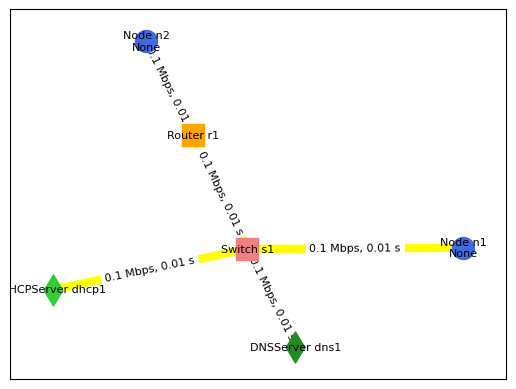

Node n1 sending DHCP DISCOVER (attempt 1/3)
DHCP Server dhcp1 offering IP 192.168.1.1/24 to client 4b:a4:48:83:42:0c
Node n1 sending DHCP REQUEST for IP 192.168.1.1/24
Node n1 has been assigned the IP address 192.168.1.1/24.
Node n1 has been assigned the DNS server IP address 192.168.1.200/24.
[HTTPClient] サーバURLからIPを解決しています: www.example.com
Node n1 sending DNS query for www.example.com
[HTTPClient] 接続後にファイルを取得します: index.html
DNS resolved: www.example.com -> 192.168.2.1/24
[HTTPClient] 解決されたIP: 192.168.2.1/24
[HTTPSClient] TCP接続を要求しています(HTTPS): 192.168.2.1/24 443
Initiating TCP handshake: Sending SYN to 192.168.2.1/24:443
[HTTPSClient] Mapping HTTPS接続 192.168.1.1/24:None -> 192.168.2.1/24:443
Sending TCP packet to 192.168.2.1/24:443 Flags: SYN Seq:None Ack:None
Processing TCP packet from 192.168.1.1/24:1024 to 192.168.2.1/24:443
TCP flags: SYN
Sending TCP packet to 192.168.1.1/24:1024 Flags: SYN,ACK Seq:None Ack:None
Processing TCP packet from 192.168.2.1/24:443 to 192.168.1.1/24:1024


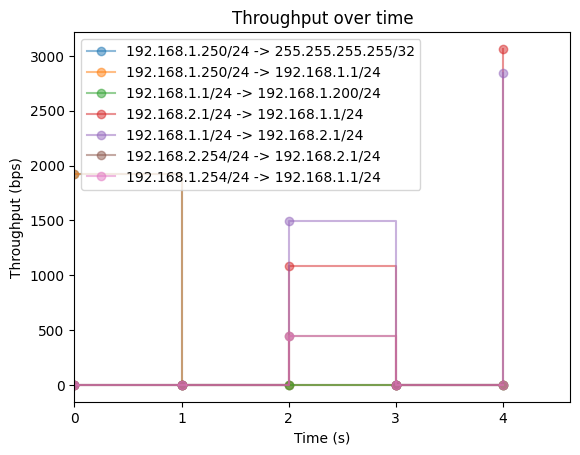

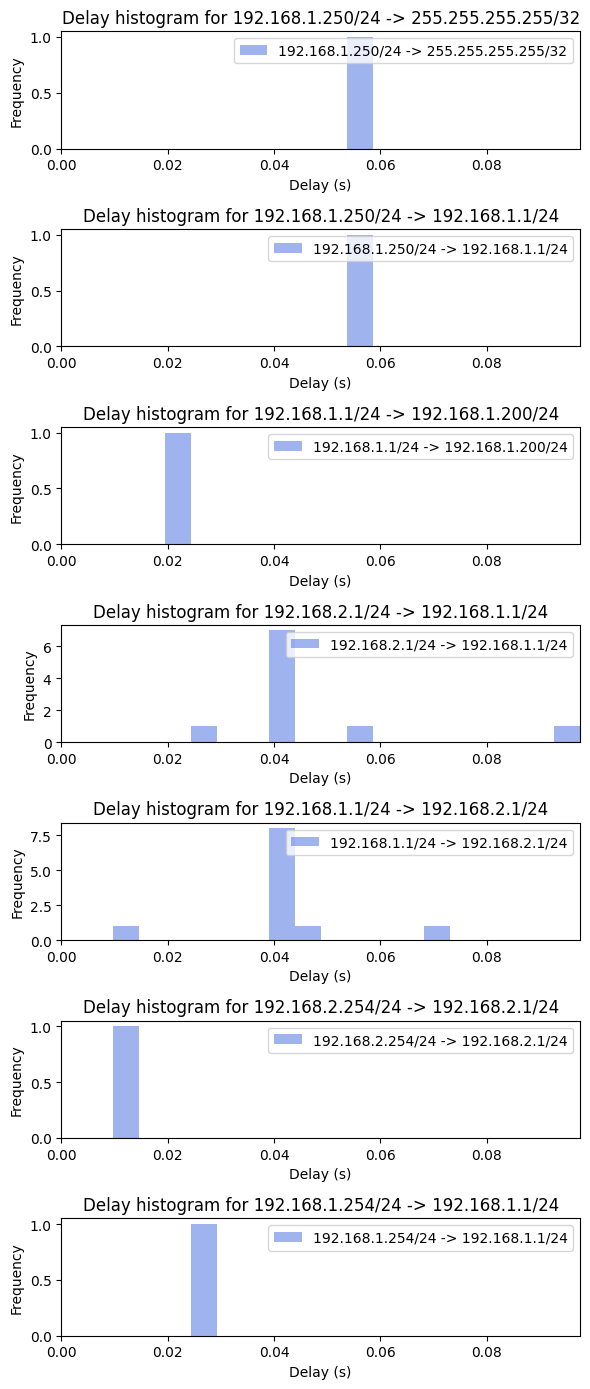

In [1]:
import sys

!git clone https://github.com/flyby-yunakayama/network-simulator.git
sys.path.insert(0,'/content/network-simulator')
%cd network-simulator

from sec15a.NetworkEventScheduler import NetworkEventScheduler
from sec15a.Node import Node
from sec15a.Switch import Switch
from sec15a.Router import Router
from sec15a.Server import DNSServer, DHCPServer
from sec15a.Link import Link
from sec15a.Application import DnsClient, DhcpClient, UDPApp, FTPClient, FTPServer, HTTPSClient, HTTPSServer

nes = NetworkEventScheduler(seed=7, log_enabled=True, verbose=False, tcp_verbose=True, link_verbose=False)

# ノードとルータの設定
node1 = Node(node_id="n1", ip_address="192.168.1.0/24", network_event_scheduler=nes)  # DHCP利用
node2 = Node(node_id="n2", ip_address="192.168.2.1/24", network_event_scheduler=nes)  # IPアドレスを静的に設定
switch1 = Switch(node_id="s1", ip_address="192.168.1.240/24", network_event_scheduler=nes)
router1 = Router(node_id="r1", ip_addresses=["192.168.1.254/24", "192.168.2.254/24"], network_event_scheduler=nes)
dns1 = DNSServer(node_id="dns1", ip_address="192.168.1.200/24", network_event_scheduler=nes)
dhcp1 = DHCPServer(node_id="dhcp1", ip_address="192.168.1.250/24", dns_server_ip="192.168.1.200/24", start_cidr="192.168.1.0/24", network_event_scheduler=nes)

# リンクの設定
link1 = Link(node1, switch1, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)
link2 = Link(switch1, router1, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)
link3 = Link(dns1, switch1, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)
link4 = Link(dhcp1, switch1, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)
link5 = Link(node2, router1, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)

# ネットワークのトポロジを描画
nes.draw()

# DNSサーバに対してDNSレコード設定
dns1.add_dns_record("www.example.com", "192.168.2.1/24")

# DHCPサーバに対して使用済みIPアドレス登録
used_ips = ["192.168.1.240/24", "192.168.1.254/24", "192.168.1.200/24", "192.168.1.250/24"]
dhcp1.mark_ips_as_used(used_ips)

# HTTPSサーバの設定 (ポート443)
shared_files = {
    "index.html": b"<h1>Welcome to Secure example.com!</h1>",
    "secret.txt": b"TopSecretData",
    "large.dat": b"X" * 10000  # 10KB file for testing
}
https_server = HTTPSServer(node2, shared_files=shared_files, verbose=True)
node2.register_application(443, "TCP", https_server)  # HTTPSサーバをApplicationManagerに登録

# HTTPSクライアントの設定
https_client = HTTPSClient(node1, verbose=True)
node1.register_application(0, "TCP", https_client)  # HTTPSクライアントをApplicationManagerに登録

def start_https_download():
    https_client.connect(server_url="www.example.com", server_port=443)
    https_client.get_file("index.html")

# HTTPSダウンロードを2秒後に開始
nes.schedule_event(2.0, start_https_download)

# イベントスケジューラを実行
nes.run_until(10.0)

# フォワーディングテーブルやルーティングテーブルを確認
node1.print_arp_table()
node1.print_url_to_ip_mapping()
node1.print_tcp_connections()
router1.print_arp_table()
router1.print_routing_table()
node2.print_arp_table()
node2.print_tcp_connections()

# 結果を確認
nes.generate_summary(nes.packet_logs)
nes.generate_throughput_graph(nes.packet_logs)
nes.generate_delay_histogram(nes.packet_logs)
#nes.plot_cwnd_log()


### 演習課題1：基本的なファイル転送

#### 目的


## 本章のまとめ

本章では、SSL/TLSおよび、それを利用したHTTPSを題材にして、暗号化によるセキュアな通信について学習しました。クライアントとサーバ間で、TCPハンドシェイクに続いてTLSハンドシェイクを実施し、暗号鍵の交換を行った上でHTTPS通信を行います。通常のHTTPでは平文すなわち誰にでも解読できる形式でデータを送受信するため盗聴などに対して脆弱であるのに対して、暗号化することで鍵を保持した送受信者のみが解読可能な暗号文となります。このようなセキュリティ技術は現代のインターネットでは必須となっており、現在ではHTTPSの利用が基本的に必須な状況になっています。
